In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [7]:
# Set Random Seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# Load Dataset
train_df = pd.read_csv("/content/sample_data/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/sample_data/fashion-mnist_test.csv")

In [9]:
print(train_df.shape)
print(test_df.shape)

(60000, 785)
(10000, 785)


In [10]:
train_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,...,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,21,68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,187,189,...,230,237,229,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,116,112,136,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,0,83,155,136,116,148,110,118,67,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,118,...,199,165,108,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,159,6,91,0,0,85,159,0,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,0,1,0,0,87,114,77,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,...,228,229,231,231,218,230,255,0,0,0,0,0,0,0,0,0,0,0,116,140,147,166,176,174,173,173,174,173,177,164,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
# Class names:

class_names = {
    0:'T-shirt',
    1:'Trouser',
    2:'Pullover',
    3:'Dress',
    4:'Coat',
    5:'Sandal',
    6:'Shirt',
    7:'Sneaker',
    8:'Bag',
    9:'Ankle Boot'
}

In [12]:
# Prepare Features and Labels
X = train_df.drop("label", axis = 1).values

y = train_df["label"].values

In [14]:
# Normalize Images
X = X / 255.0

In [16]:
# Reshape the Images -> (samples, height, width, channels)

X = X.reshape(-1, 28, 28, 1)

In [18]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state=42,
    stratify=y
)

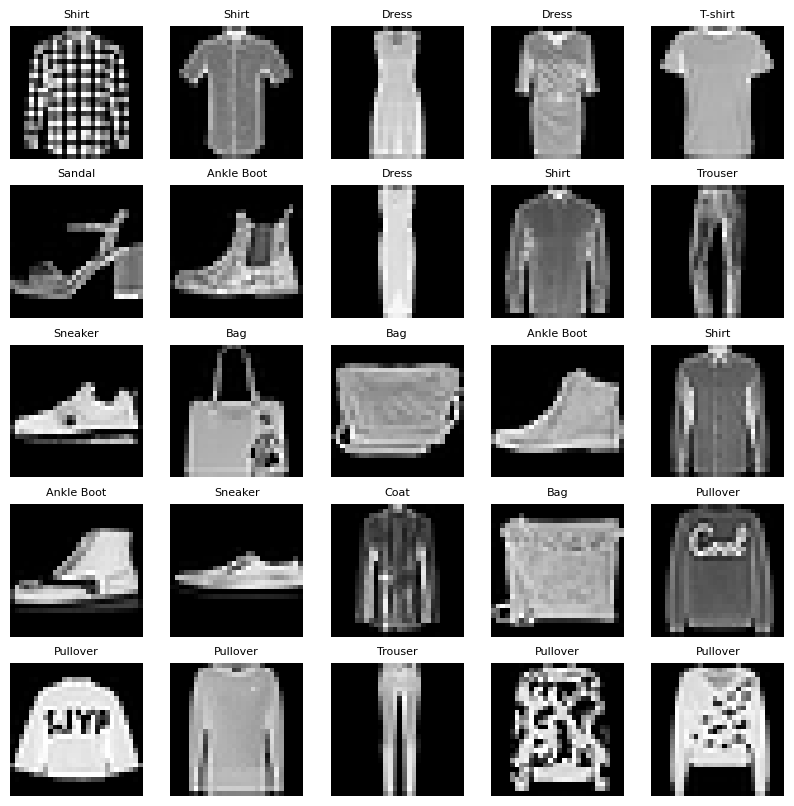

In [21]:
# Visualize Samples

plt.figure(figsize=(10, 10))

for i in range(25):
  plt.subplot(5,5, i+1)

  plt.imshow(
      X_train[i].reshape(28, 28),
      cmap = 'gray'
  )

  plt.title(
      class_names[y_train[i]],
      fontsize = 8
  )

  plt.axis('off')

plt.show()

In [22]:
# Data Augmentation

datagen = ImageDataGenerator(
    rotation_range = 10,
    zoom_range = 0.10,
    width_shift_range = 0.10,
    height_shift_range = 0.10
)

datagen.fit(X_train)

In [23]:
# Build Advanced CNN

In [26]:
model = Sequential()

#block 1

model.add(
    Conv2D(
        32,
        (3,3),
        padding = 'same',
        activation = 'relu',
        input_shape = (28,28,1)
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        32,
        (3,3),
        padding = 'same',
        activation = 'relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))

# Block 2

model.add(
    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(
    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D())

model.add(Dropout(0.25))

# Block 3

model.add(
    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D())

model.add(Dropout(0.30))

# Dense Layers

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(BatchNormalization())

model.add(Dropout(0.50))

model.add(Dense(10, activation='softmax'))



In [27]:
# Model Summary


In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [29]:
# Compile Model
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [33]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1

)

checkpoint = ModelCheckpoint(

    'best_fashion_model.keras',

    save_best_only=True,

    monitor='val_accuracy',

    mode='max'

)

In [35]:
# Train Model
history = model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=128
    ),

    validation_data=(X_test,y_test),

    epochs=30,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 358s 932ms/step - accuracy: 0.7050 - loss: 0.8294 - val_accuracy: 0.3473 - val_loss: 2.5439 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 348s 928ms/step - accuracy: 0.8008 - loss: 0.5329 - val_accuracy: 0.8570 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 352s 938ms/step - accuracy: 0.8330 - loss: 0.4545 - val_accuracy: 0.8677 - val_loss: 0.3457 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 352s 938ms/step - accuracy: 0.8475 - loss: 0.4143 - val_accuracy: 0.8850 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 338s 901ms/step - accuracy: 0.8601 - loss: 0.3843 - val_accuracy: 0.8782 - val_loss: 0.3067 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.8664 - loss: 0.3656
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 ━━━━━━━━━━━━━━━━━━━━ 349s 932ms/step - accuracy:

In [37]:
# Evaluate Model
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9155833125114441


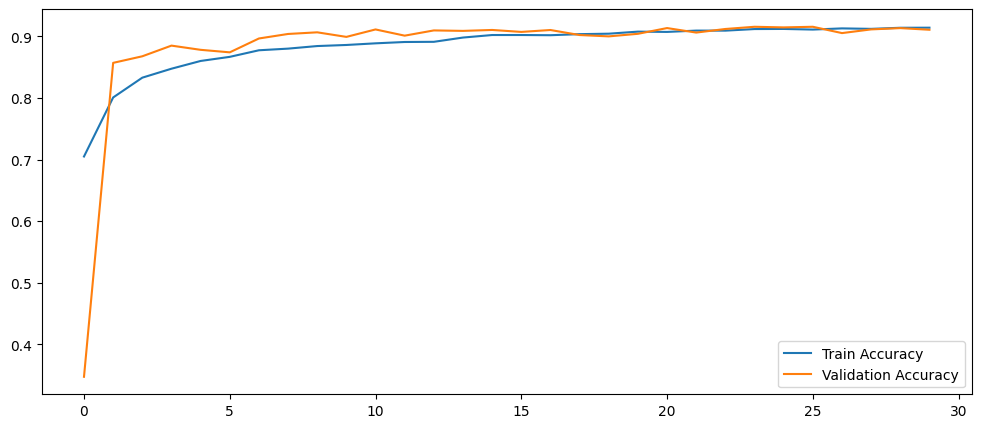

In [38]:
# Learning Curve
plt.figure(figsize=(12,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.show()

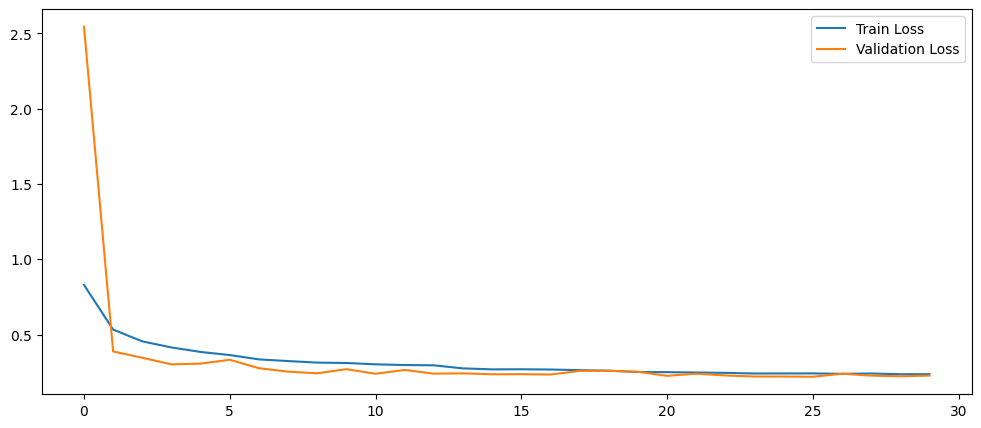

In [39]:
# Loss Curve
plt.figure(figsize=(12,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.show()

In [40]:
# Predictions

pred_probs = model.predict(X_test)

predictions = np.argmax(
    pred_probs,
    axis=1
)

375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step


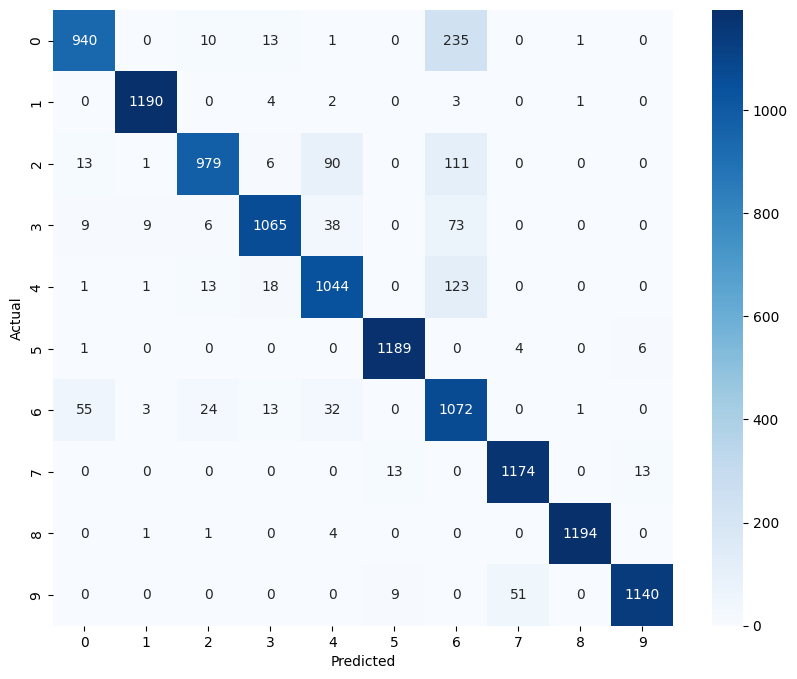

In [42]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
# Classification Report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.78      0.85      1200
           1       0.99      0.99      0.99      1200
           2       0.95      0.82      0.88      1200
           3       0.95      0.89      0.92      1200
           4       0.86      0.87      0.87      1200
           5       0.98      0.99      0.99      1200
           6       0.66      0.89      0.76      1200
           7       0.96      0.98      0.97      1200
           8       1.00      0.99      1.00      1200
           9       0.98      0.95      0.97      1200

    accuracy                           0.92     12000
   macro avg       0.93      0.92      0.92     12000
weighted avg       0.93      0.92      0.92     12000



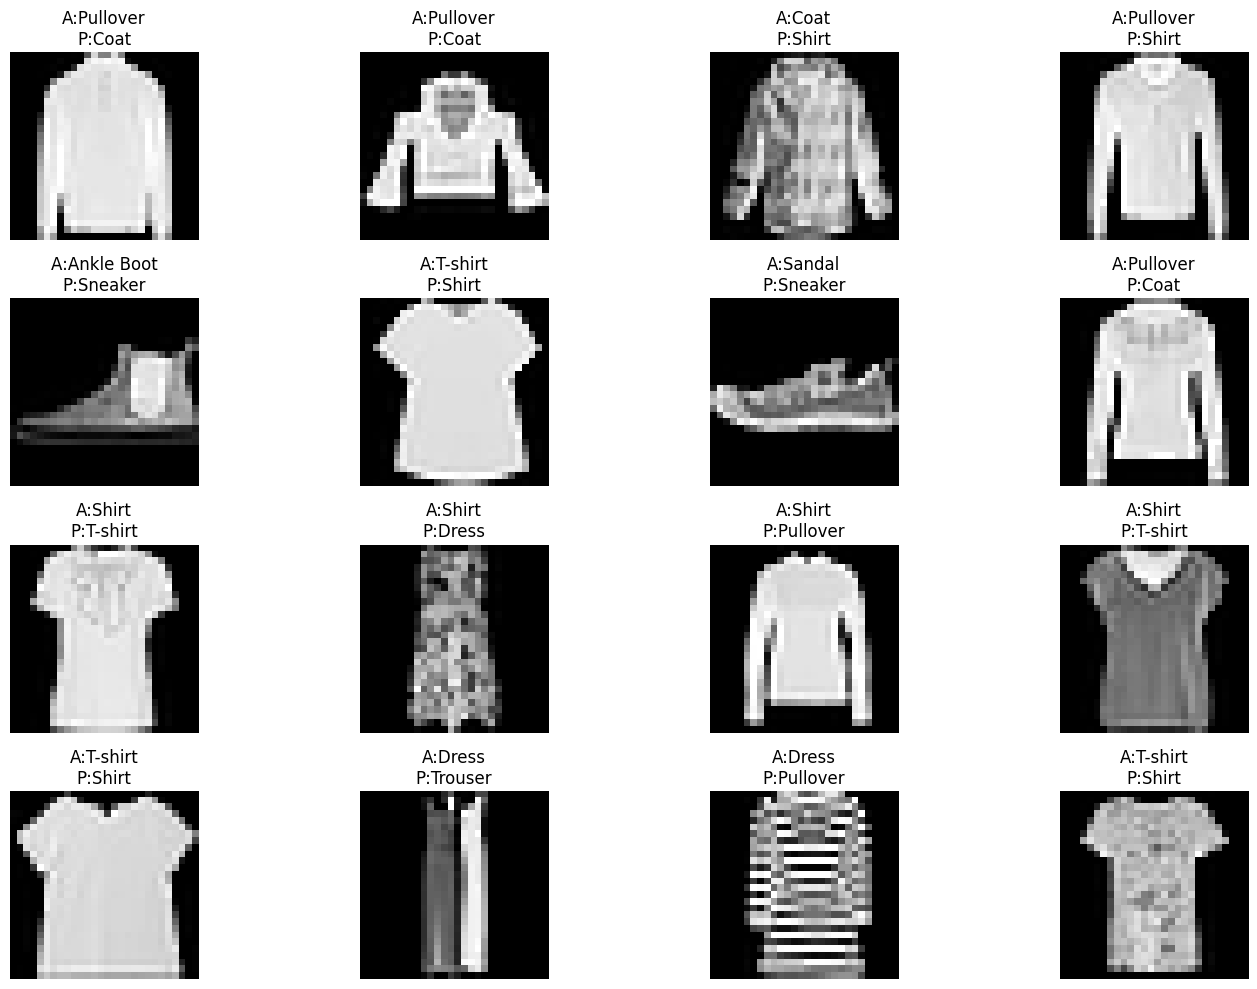

In [47]:
# Show Wrong Prediction

incorrect = np.where(
    predictions != y_test
)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(incorrect[:16]):

    plt.subplot(4,4,i+1)

    plt.imshow(
        X_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"A:{class_names[y_test[idx]]}\nP:{class_names[predictions[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
# save model

model.save(
    "fashion_mnist.keras"
)

In [51]:
# Load Save model

loaded_model = tf.keras.models.load_model(
    "fashion_mnist.keras"
)

In [52]:
# Predict New Image

sample = X_test[0]

prediction = loaded_model.predict(
    sample.reshape(1,28,28,1)
)

predicted_class = np.argmax(
    prediction
)

print(
    class_names[predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
Sandal
